In [1]:
#Imports 
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
#from DiscEvolution.eos import LocallyIsothermalEOS  
#from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
#from DiscEvolution.disc import AccretionDisc
#from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.internal_photo import ConstantInternalPhotoevap

# Increase resolution (DPI) for better quality
plt.rcParams['figure.dpi'] = 300 

In [2]:
#Initialized but value given in next cell
M_disk_0 = None
Rc = None
R_in = None
Mdot_0 = None
Mstar = None
Rstar = None
# LBP surface density profile with gamma = 1: Sigma(r) = (M_disk / (2*pi*Rc*r)) * exp(-r/Rc)
def Sigma_LBP_1(r) -> float:
    val = (M_disk_0)/(2* np.pi * Rc * r) * np.exp((-1*r)/(Rc))
    if (val.cgs.unit != (u.g / (u.cm)**2)):
        print("Sigma_1 error")
        return 0
    return val.cgs

def Temperature(r) -> float:
    T_0 = 150 * u.K 
    val  = T_0 * (r / (1.0 * u.AU))**(-1/2)
    if val.cgs.unit != u.K:
        print('Temperature error')
        return 0
    return val.cgs

def Omega(r) -> float:
    val = np.sqrt((const.G*Mstar)/(r**3))
    if (val.cgs.unit != (1 / u.s)): 
        print("Omega error")
        return 0
    return val.cgs

def c_s(r) -> float:
    val = np.sqrt((const.k_B*Temperature(r))/(mu*const.m_p))
    if (val.cgs.unit != (u.cm / u.s)): 
        print("c_s error")
        return 0
    return val.cgs

def H(r) -> float: 
    val = c_s(r)/Omega(r)
    if val.cgs.unit != (u.cm):
        print("H error")
        return 0
    return val.cgs

#Given Mdisk, Mdot(0), Rc -> Calculate alpha and Sigma0
def calculateAlpha() -> float:
    Rin_cgs = (R_in * u.AU).to(u.cm)               #cm
    Mdot_cgs = Mdot_0.to(u.g / u.s).value  # g/s
    M_disk_cgs = M_disk_0.cgs.value         #g
    cs_val = c_s(Rin_cgs).value                   # cm/s
    omega = Omega(Rin_cgs).value                   # 1/s
    Rc_cgs = Rc.cgs.value               #cm
    alpha = Mdot_cgs*((2*Rin_cgs.value*omega)/3) * (Rc_cgs/((cs_val**2) * M_disk_cgs))
    return alpha 

In [3]:
t_final = 1 * u.Myr
t_final_yr = t_final.to(u.yr).value 
t_final_code = t_final_yr * yr_code  #Convert to code units

M_disk_0 = 0.05 * u.solMass
Mdot_0 = 1E-8 * u.solMass / u.yr  #Armitage p.21
Mstar = 1.0 * u.AU
Rstar = 1.0 * u.AU
Rc = 100.0 * u.AU

alpha_eff = 1e-3
psi = 100
alpha_turb = alpha_eff / (1.0 + psi)   
alpha_wind = psi * alpha_turb          #Not used for calculations, just for prints

print(f"\nalpha_eff: {alpha_eff:.0e}")
print(f"alpha_turb: {alpha_turb:.0e}")
print(f"alpha_wind: {alpha_wind:.0e}")


alpha_eff: 1e-03
alpha_turb: 1e-05
alpha_wind: 1e-03


In [4]:
# 1) Create grid
R_in = 0.1 #AU
R_out = 1000.0  # AU
Ncells = 500
grid = Grid(R_in, R_out, Ncells, spacing='natural')

In [5]:
# 2) Create star
star = SimpleStar(M = Mstar.value ,R = Rstar.value, T_eff = 4000.0)  #Msun, Rsun, K

In [6]:
# 3) Create EOS 
eos = IrradiatedEOS(
    star,
    alpha_t=alpha_turb,   # Turbulent alpha
    Tc=10,                # External/nebular temperature floor (K)
    Tmax=1500,            # Maximum temperature cap (K)
    mu=2.33,
    gamma=1.0,
    accrete=True,          # Include viscous heating from accretion
    kappa=Zhu2012
)

eos.set_grid(grid)

In [7]:
# 4) Create surface density array from LBP profile
R_centers = grid.Rc  # AU
Sigma_initial = np.array([Sigma_LBP_1(r * u.AU).value for r in R_centers])

eos.update(0, Sigma_initial)

/Users/james/Documents/GitHub/DiscEvolution/DiscEvolution/eos.py:459: RuntimeWarning: divide by zero encountered in divide
  return 1. / Pr_1


In [8]:
# 5) Create the disc with dust
disc = DustGrowthTwoPop(
    grid, 
    star, 
    eos, 
    eps=0.01,              # Initial dust-to-gas ratio (1%)
    Sigma=Sigma_initial,
    feedback=True,         # Dust affects gas dynamics
    f_ice=1,             # Ice fraction (affects fragmentation)
    uf_0=100,             # Fragmentation velocity for dry grains (cm/s)
    uf_ice=1000,           # Fragmentation velocity for icy grains (cm/s)
    thresh=0.1             # Threshold for ice effects
)

disc._planetesimal = False #Turn off planetessimals for now
disc.update(0.0) #This is to have the pebble size and stokes number correct at t=0

In [9]:
# 6) Set up evolution
visc_evol = HybridWindModel(psi_DW=psi, lambda_DW=3, tol=0.5, boundary='power_law', in_bound='Mdot')
disc._gas = visc_evol #FIXES AN ERROR IN TORQUE CALCS

drift = SingleFluidDrift(diffusion=None, settling=True)
driver = PlanetDiscDriver(disc, gas=visc_evol, dust=drift, t0=0.0)

In [10]:
#Check timestep size
dt_max = visc_evol.max_timestep(disc) / yr_code
print(f"dt_max = {dt_max:.1f} years")
print(f"Estimated steps: {t_final_code/dt_max:.0f}")

#Output times (in code units)
output_times_yr = np.linspace(0, t_final_yr, 11)  # Every 100 kyr
output_times_code = output_times_yr * yr_code
snapshot_times_yr = np.array([1e5, 5e5, 1e6])  # Snapshot times in years
snapshot_times_code = snapshot_times_yr * yr_code  # Convert to code units
io = Event_Controller(save=output_times_code, snapshot=snapshot_times_code)

history = {'t_yr': [], 'Mtot': [], 'Rout': [], 'dt_yr': []}
snapshots = {'t_yr': [], 'Sigma_G': [], 'Sigma_D': [], 'dust_frac': [], 'St': [], 'grain_size': [], 'T': [], 'P': []}

#t = 0 history 
dt_current = visc_evol.max_timestep(disc)
history['t_yr'].append(driver.t / yr_code)
history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
history['Rout'].append(disc.Rout())
history['dt_yr'].append(dt_current / yr_code)

#t = 0 snapshot
snapshots['t_yr'].append(0.0)
snapshots['Sigma_G'].append(disc.Sigma_G.copy())
snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
snapshots['St'].append(disc.Stokes()[1].copy())  #Pebbles not small grains
snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
snapshots['T'].append(disc.T.copy()) #Temp
snapshots['P'].append(disc.P.copy()) #Pressure

dt_max = 1898.2 years
Estimated steps: 3310


In [ ]:
print(f"\nStarting disc evolution...")
pbar = tqdm(total=t_final_yr, unit='yr', desc='Evolving disc...')
last_t_yr = 0.0
steps = 0

while not io.finished():
    ti = io.next_event_time()

    while driver.t < ti:
        dt = driver(ti)
        steps += 1
        
        #pbar progress
        t_yr = driver.t / yr_code
        pbar.update(t_yr - last_t_yr)
        last_t_yr = t_yr

    # Store snapshots at snapshot times
    if io.check_event(driver.t, 'snapshot'):
        snapshots['t_yr'].append(t_yr)
        snapshots['Sigma_G'].append(disc.Sigma_G.copy())
        snapshots['Sigma_D'].append(disc.Sigma_D.sum(axis=0).copy()) #Total dust Sigma, pebbles + grains
        snapshots['dust_frac'].append(disc.dust_frac.sum(axis=0).copy()) #Total dust to gas ratio
        snapshots['St'].append(disc.Stokes()[1].copy()) #Pebbles not small grains
        snapshots['grain_size'].append(disc.grain_size[1].copy()) #Pebbles not small grains
        snapshots['T'].append(disc.T.copy()) #Temp
        snapshots['P'].append(disc.P.copy()) #Pressure
        io.pop_events(driver.t, 'snapshot')

    # Store at output times
    if io.check_event(driver.t, 'save'):
        dt_current = visc_evol.max_timestep(disc)
        history['t_yr'].append(driver.t / yr_code)
        history['Mtot'].append(disc.Mtot() * u.g.to(u.solMass))
        history['Rout'].append(disc.Rout())
        history['dt_yr'].append(dt_current / yr_code)
        io.pop_events(driver.t, 'save')
        
pbar.close()
print(f"\n=== EVOLUTION COMPLETE ===")
print(f"Total steps: {steps}")
print(f"Final time: {driver.t/yr_code:.1e} years")
print(f"Final mass: {history['Mtot'][-1]:.3e} M_sun ({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% of initial)")
print(f"Average dt: {np.mean(history['dt_yr']):.1f} years")



Starting disc evolution...


Evolving disc...:   0%|          | 0/1000000.0 [00:00<?, ?yr/s]

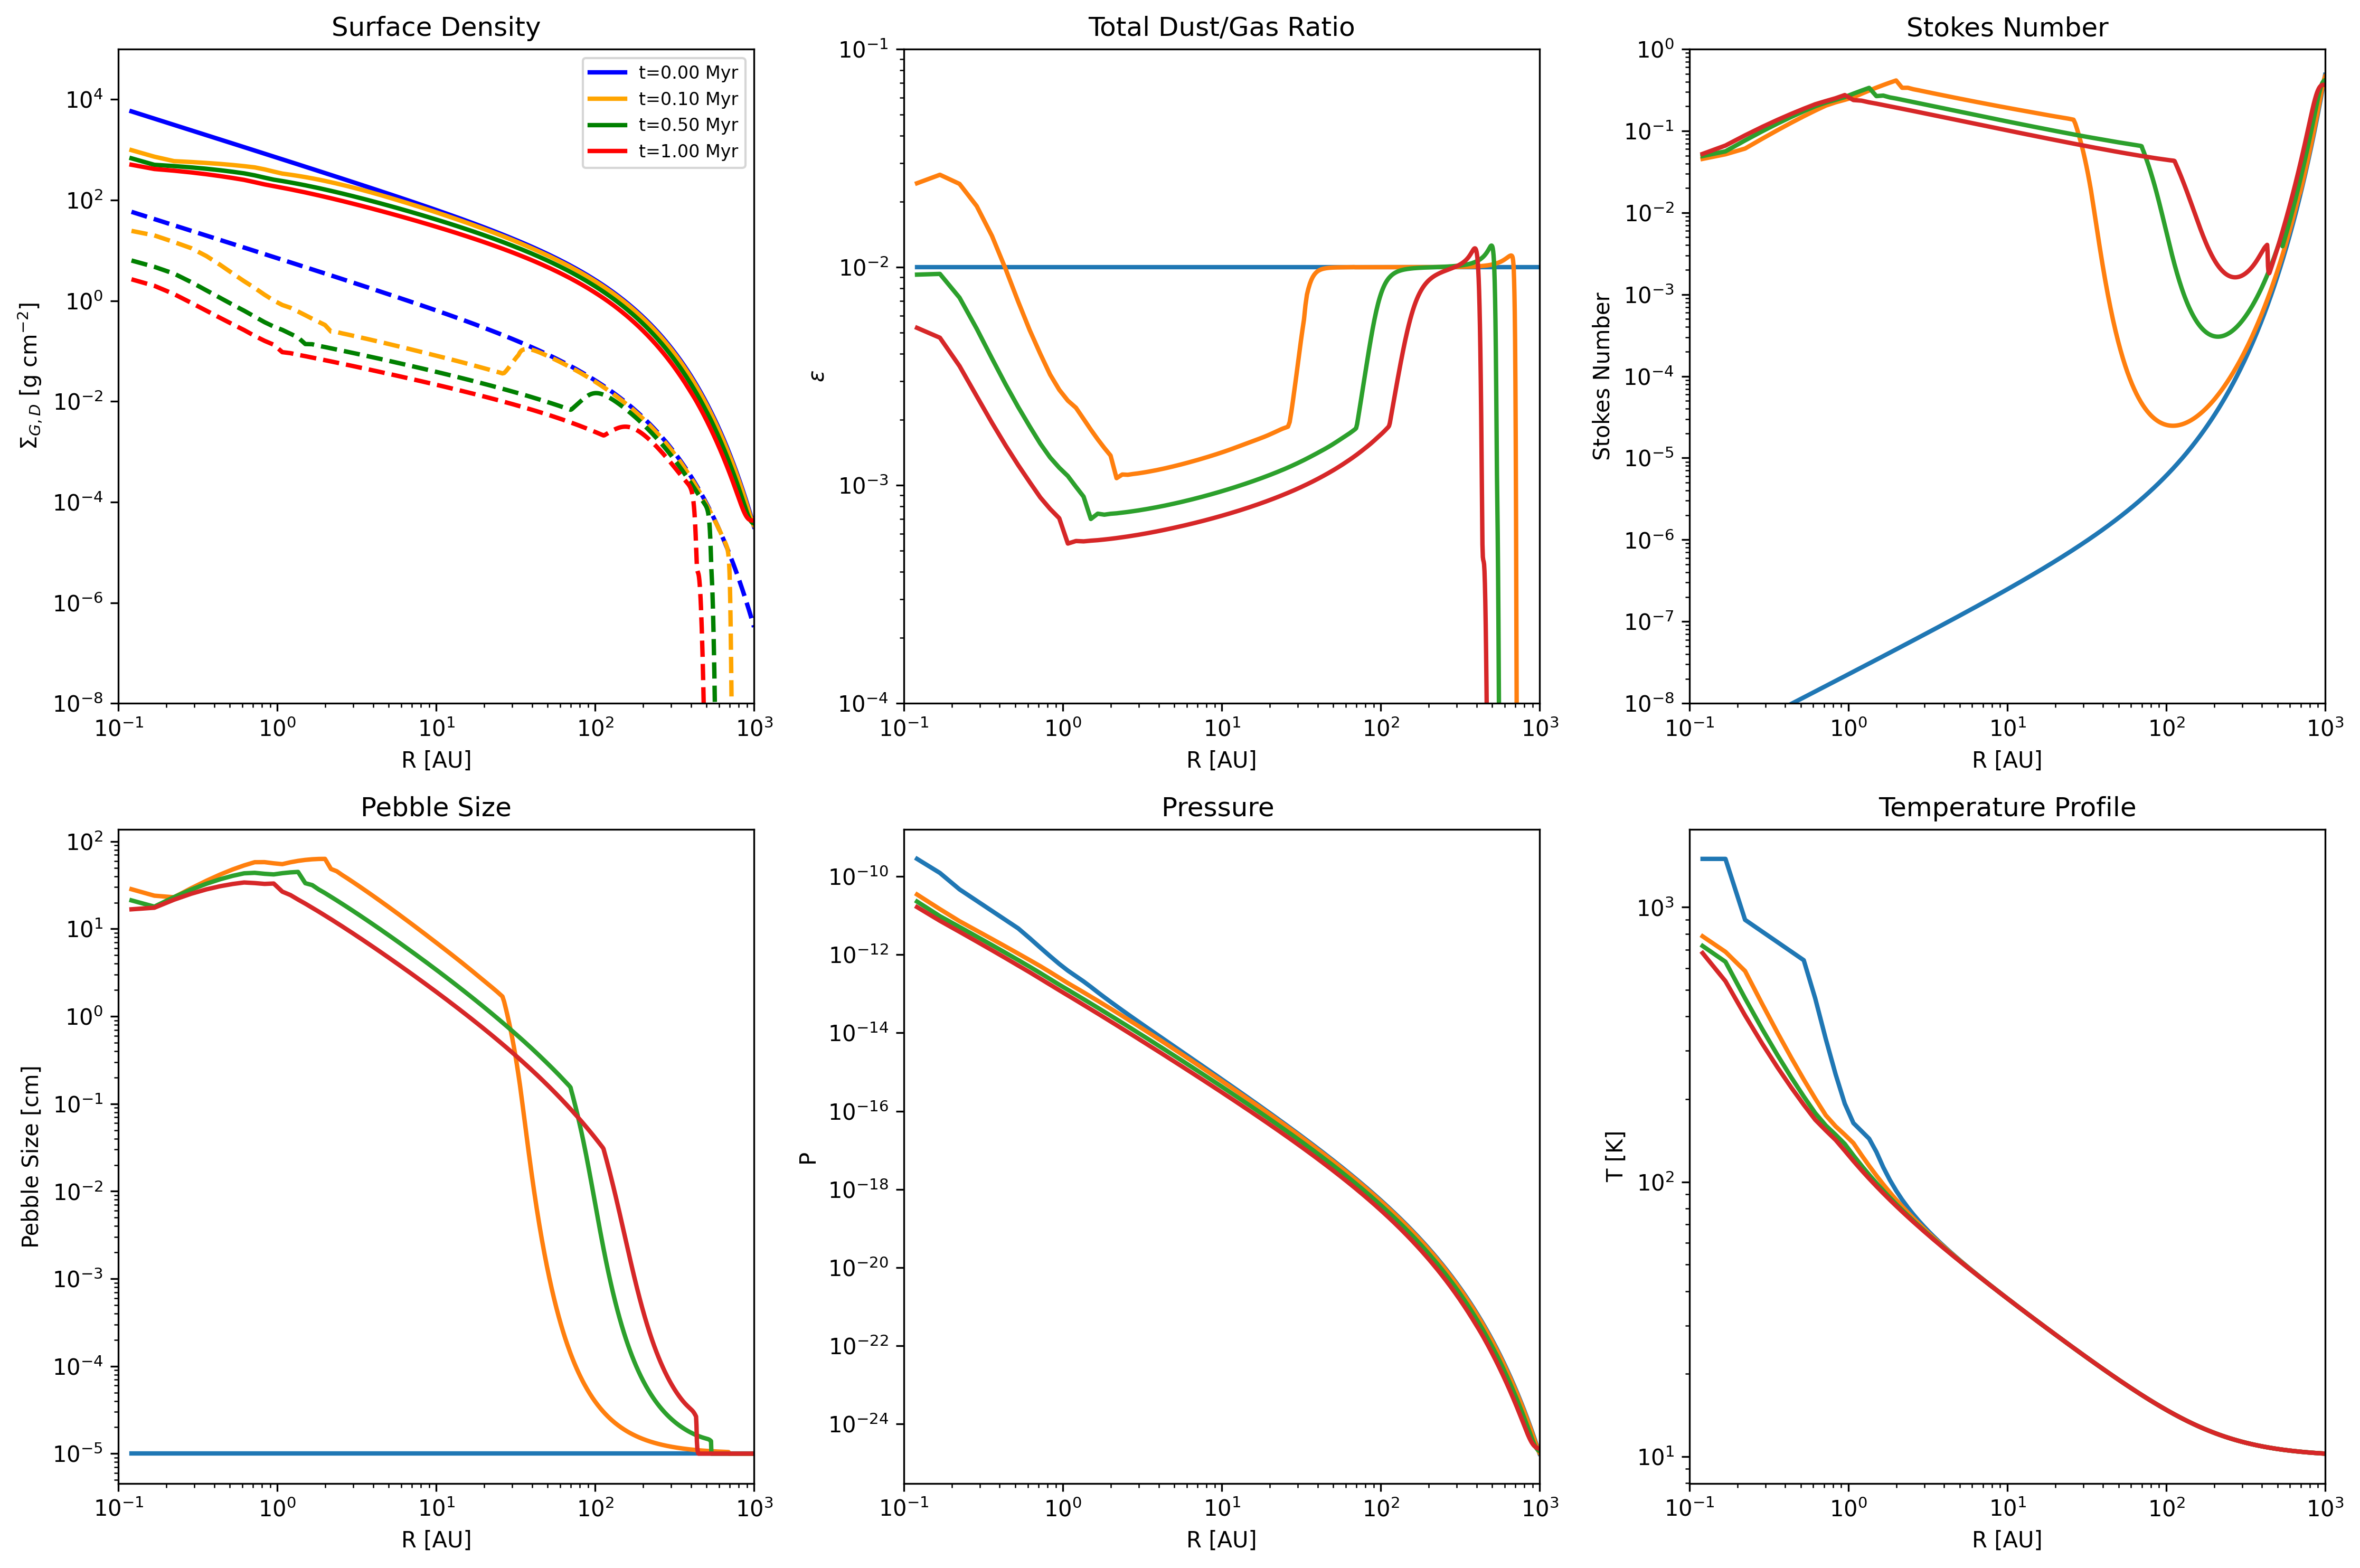


=== Summary ===
Initial mass: 4.995e-02 M_sun
Final mass:   1.394e-02 M_sun (27.9% remaining)
Final dust/gas at 10 AU: 0.0005
Max pebble size: 20.13 cm at R = 0.6 AU


In [ ]:
# Plot evolution results with dust properties
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Surface density: Gas and Dust
ax = axes[0, 0]
#ax.loglog(disc.R, Sigma_initial, 'k--', label='Initial Total', alpha=0.5)
#ax.loglog(disc.R, disc.Sigma_G, 'k-', label='Gas', lw=2)
#ax.loglog(disc.R, disc.Sigma_D.sum(axis=0), 'k--', label='Dust (Total)', lw=2)
#ax.loglog(disc.R, disc.Sigma_D[0], 'g--', label='Small Dust')
#ax.loglog(disc.R, disc.Sigma_D[1], 'r:', label='Pebbles', lw=2)

from cycler import cycler
c = ['blue','orange','g','r']
ax.set_prop_cycle(cycler(color=c))

i = 0
for line in snapshots['Sigma_G']:
    ax.loglog(disc.R, line, linestyle = 'solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1

i = 0
for line in snapshots['Sigma_D']:
    ax.loglog(disc.R, line, linestyle = 'dashed', lw=2)
    i += 1
ax.set_ylim(1e-8,1e5)
ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\Sigma_{G,D}$ [g cm$^{-2}$]')
ax.set_title('Surface Density')
ax.legend(fontsize=8)
ax.set_xlim(R_in, R_out)

# 2. Dust-to-gas ratio (epsilon)
ax = axes[0, 1]
#ax.loglog(disc.R, disc.dust_frac[0], 'g--', label='Small grains')
#ax.loglog(disc.R, disc.dust_frac[1], 'r-', label='Pebbles', lw=2)
#ax.loglog(disc.R, disc.dust_frac.sum(0), 'k-', label='Total', lw=2)
#ax.axhline(0.01, ls=':', color='gray', alpha=0.5, label='Initial (1%)')

i = 0
for line in snapshots['dust_frac']:
    ax.loglog(disc.R, line, linestyle = 'solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel(r'$\epsilon$')
ax.set_title('Total Dust/Gas Ratio')
#ax.legend(fontsize=8)
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-4,1e-1)

# 3. Stokes number (Stokes() is a method, returns [small, large] array)
ax = axes[0, 2]
#St = disc.Stokes()  # Call the method
#ax.loglog(disc.R, St[0], 'g--', label='Small grains')
#ax.loglog(disc.R, St[1], 'r-', label='Pebbles', lw=2)
#ax.axhline(1.0, ls=':', color='gray', alpha=0.5, label='St = 1')

i = 0
for line in snapshots['St']:
    ax.loglog(disc.R, line, linestyle = 'solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('Stokes Number')
ax.set_title('Stokes Number')
#ax.legend(fontsize=9)
ax.set_xlim(R_in, R_out)
ax.set_ylim(1e-8,1e0)

# 4. Pebble size
ax = axes[1, 0]
#ax.loglog(disc.R, disc.grain_size[0], 'g--', label='Small grains')
#ax.loglog(disc.R, disc.grain_size[1], 'r-', label='Pebbles', lw=2)

i = 0
for line in snapshots['grain_size']:
    ax.loglog(disc.R, line, linestyle = 'solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1


ax.set_xlabel('R [AU]')
ax.set_ylabel('Pebble Size [cm]')
ax.set_title('Pebble Size')
#ax.legend(fontsize=9)
ax.set_xlim(R_in, R_out)

# 5. Mass evolution
#ax = axes[1, 1]
#ax.semilogy(np.array(history['t_yr'])/1e6, np.array(history['Mtot']), '-', color='k', label=rf"({100*history['Mtot'][-1]/history['Mtot'][0]:.1f}% mass remaining)")
#ax.set_xlabel('Time [Myr]') 
#ax.set_ylabel(r'Disc Mass [M$_\odot$]')
#ax.set_title('Mass Evolution')
#ax.legend()

# 5. Pressure
ax = axes[1, 1]
i = 0
for line in snapshots['P']:
    ax.loglog(disc.R, np.abs(line), linestyle='solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1
ax.set_xlabel('R [AU]')
ax.set_ylabel('P')
ax.set_title('Pressure ')
ax.set_xlim(R_in, R_out)

# 6. Temperature profile
ax = axes[1, 2]
#ax.loglog(disc.R, disc.T, 'r-', lw=2)

i = 0
for line in snapshots['T']:
    ax.loglog(disc.R, line, linestyle = 'solid', label=rf"t={snapshots['t_yr'][i]/1e6:.2f} Myr", lw=2)
    i += 1

ax.set_xlabel('R [AU]')
ax.set_ylabel('T [K]')
ax.set_title('Temperature Profile')
ax.set_xlim(R_in, R_out)
#ax.legend()

plt.tight_layout()
#plt.savefig('Outputs/TaboneZhuNew-100.jpg', dpi=300, bbox_inches='tight')
plt.show()

### I'll do an example of torque maps computation here. 

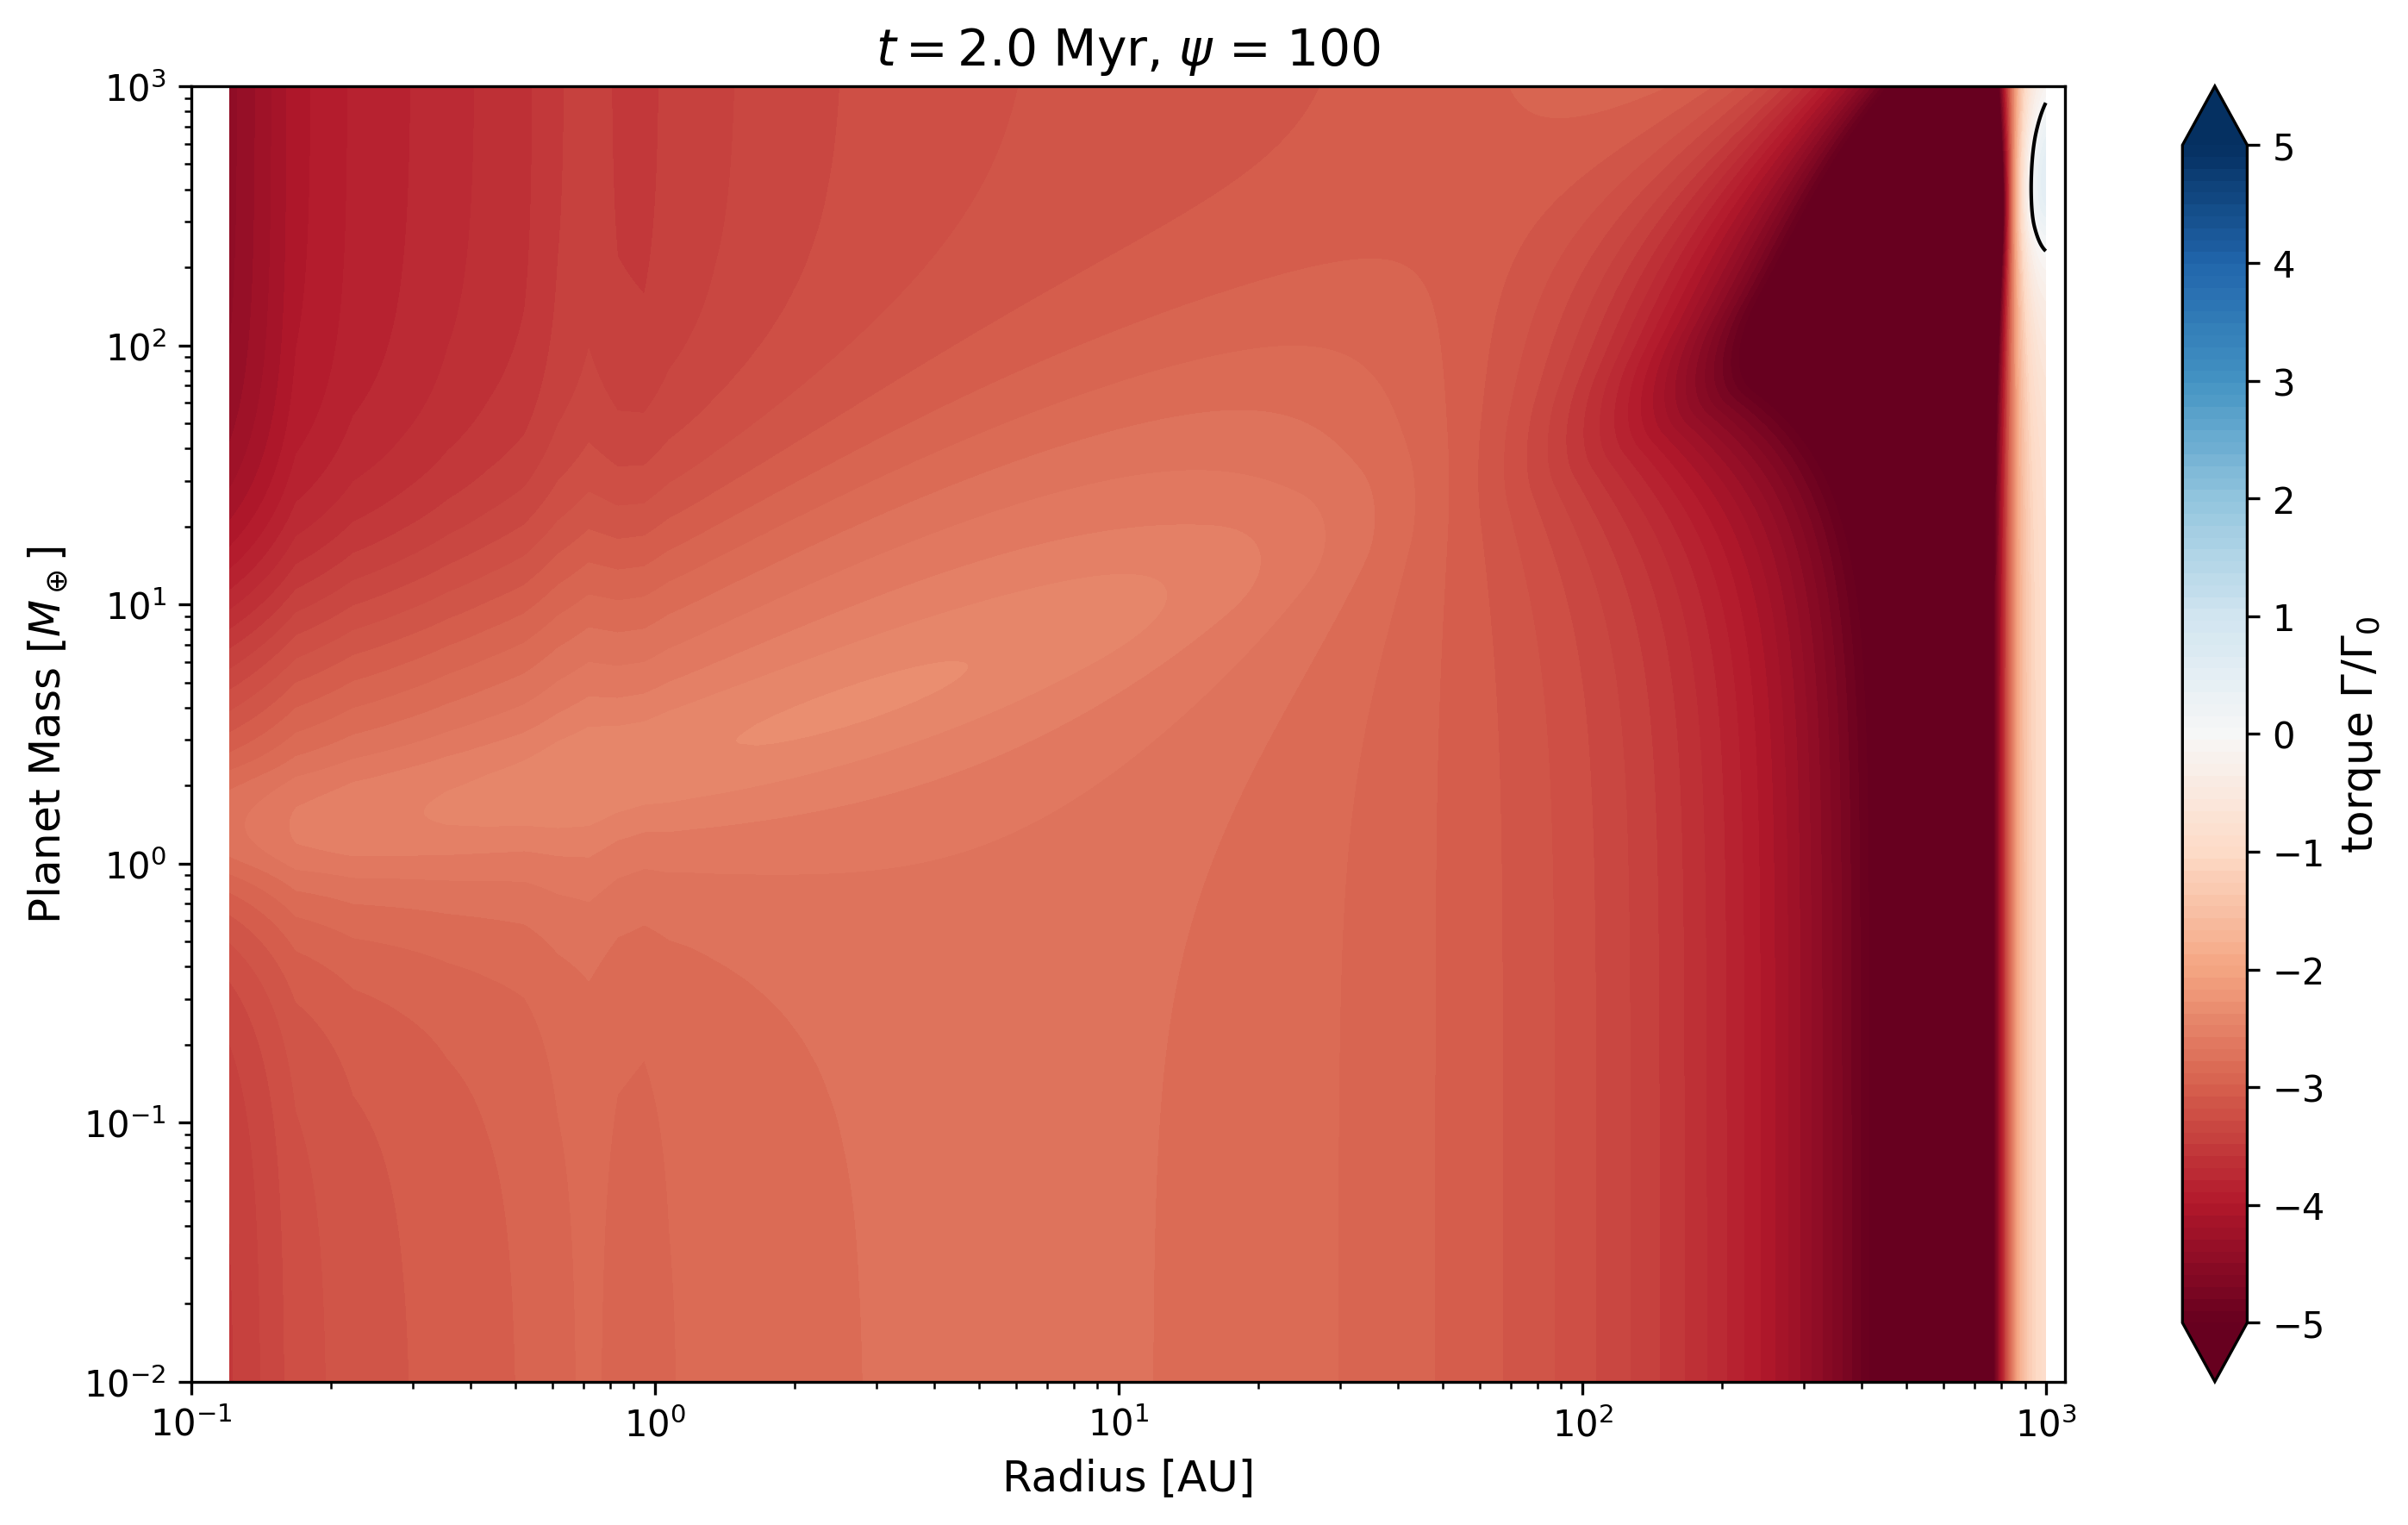

In [ ]:
disc._gas = visc_evol
from DiscEvolution import planet_formation as pf

# 1. Create Migration Model
TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object

# 2. Create M-R diagram 
mass_array = np.logspace(-2,3,Ncells) #Mearth required by compute_torque function
radius_array = disc.R #AU

R_grid, M_grid = np.meshgrid(radius_array, mass_array) #2D grid from two 1D arrays
Torque_map = np.zeros_like(R_grid) #initialize 2D grid with all values zero 

# 3. Compute Torques
for i, Mp in enumerate(mass_array):
    # Pass Mp as an array of the same shape as radius_array
    Mp_array = np.ones_like(radius_array) * Mp #entire row with said mass value
    # Compute the total torque for said mass at each R 
    Torque_map[i, :] = TypeI.compute_torque_raw(radius_array, Mp_array) #TODO get warnings after first import from the main method in planet_formation.py 

# 4. Normalize by Gamma_0
## The function already computes Gamma_0 (norm) and scales the torque with it, so we want to reverse this
## I created a new function that doesn't scale the torques so this step is not necessary anymore
##essentially instead of Gamma*Gamma_0 we return Gamma

# 5. Plot Torque Map 
from matplotlib import colors


fig, ax = plt.subplots(figsize=(10, 6))

# Colormap (Red = Inward/negative, Blue = Outward/Positive)
norm = colors.TwoSlopeNorm(vmin=-5.0, vcenter=0.0, vmax=5.0)
symmetric_levels = np.linspace(-5.0, 5.0, 100) #Explicitly define 100 levels from -5 to +5
cp = ax.contourf(R_grid, M_grid, Torque_map, levels=symmetric_levels, cmap='RdBu', norm=norm, extend='both')

# Zero-Torque Planet Traps
trap_lines = ax.contour(R_grid, M_grid, Torque_map, levels=[0.0], colors='black', linewidths=1.0)

# Colorbar
cbar = plt.colorbar(cp, ax=ax, ticks = np.arange(-5.0, 6.0, 1.0))
cbar.set_label(rf'torque $\Gamma / \Gamma_0$', fontsize=12)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 1100) 
#ax.set_ylim(0.1, 100)

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(rf'Planet Mass [$M_\oplus$]', fontsize=12)
ax.set_title(rf'$t = {driver.t / (1e6* 2 * np.pi)}$ Myr, $\psi$ = {disc._gas._psi}', fontsize=14)
    
plt.tight_layout()
#plt.savefig('output/TaboneZhu100-Torques.jpg', dpi=300)
plt.show()

In [ ]:
float(np.min(Torque_map)) , float(np.max(Torque_map))

(-10.092343259964096, 0.5447654661208823)

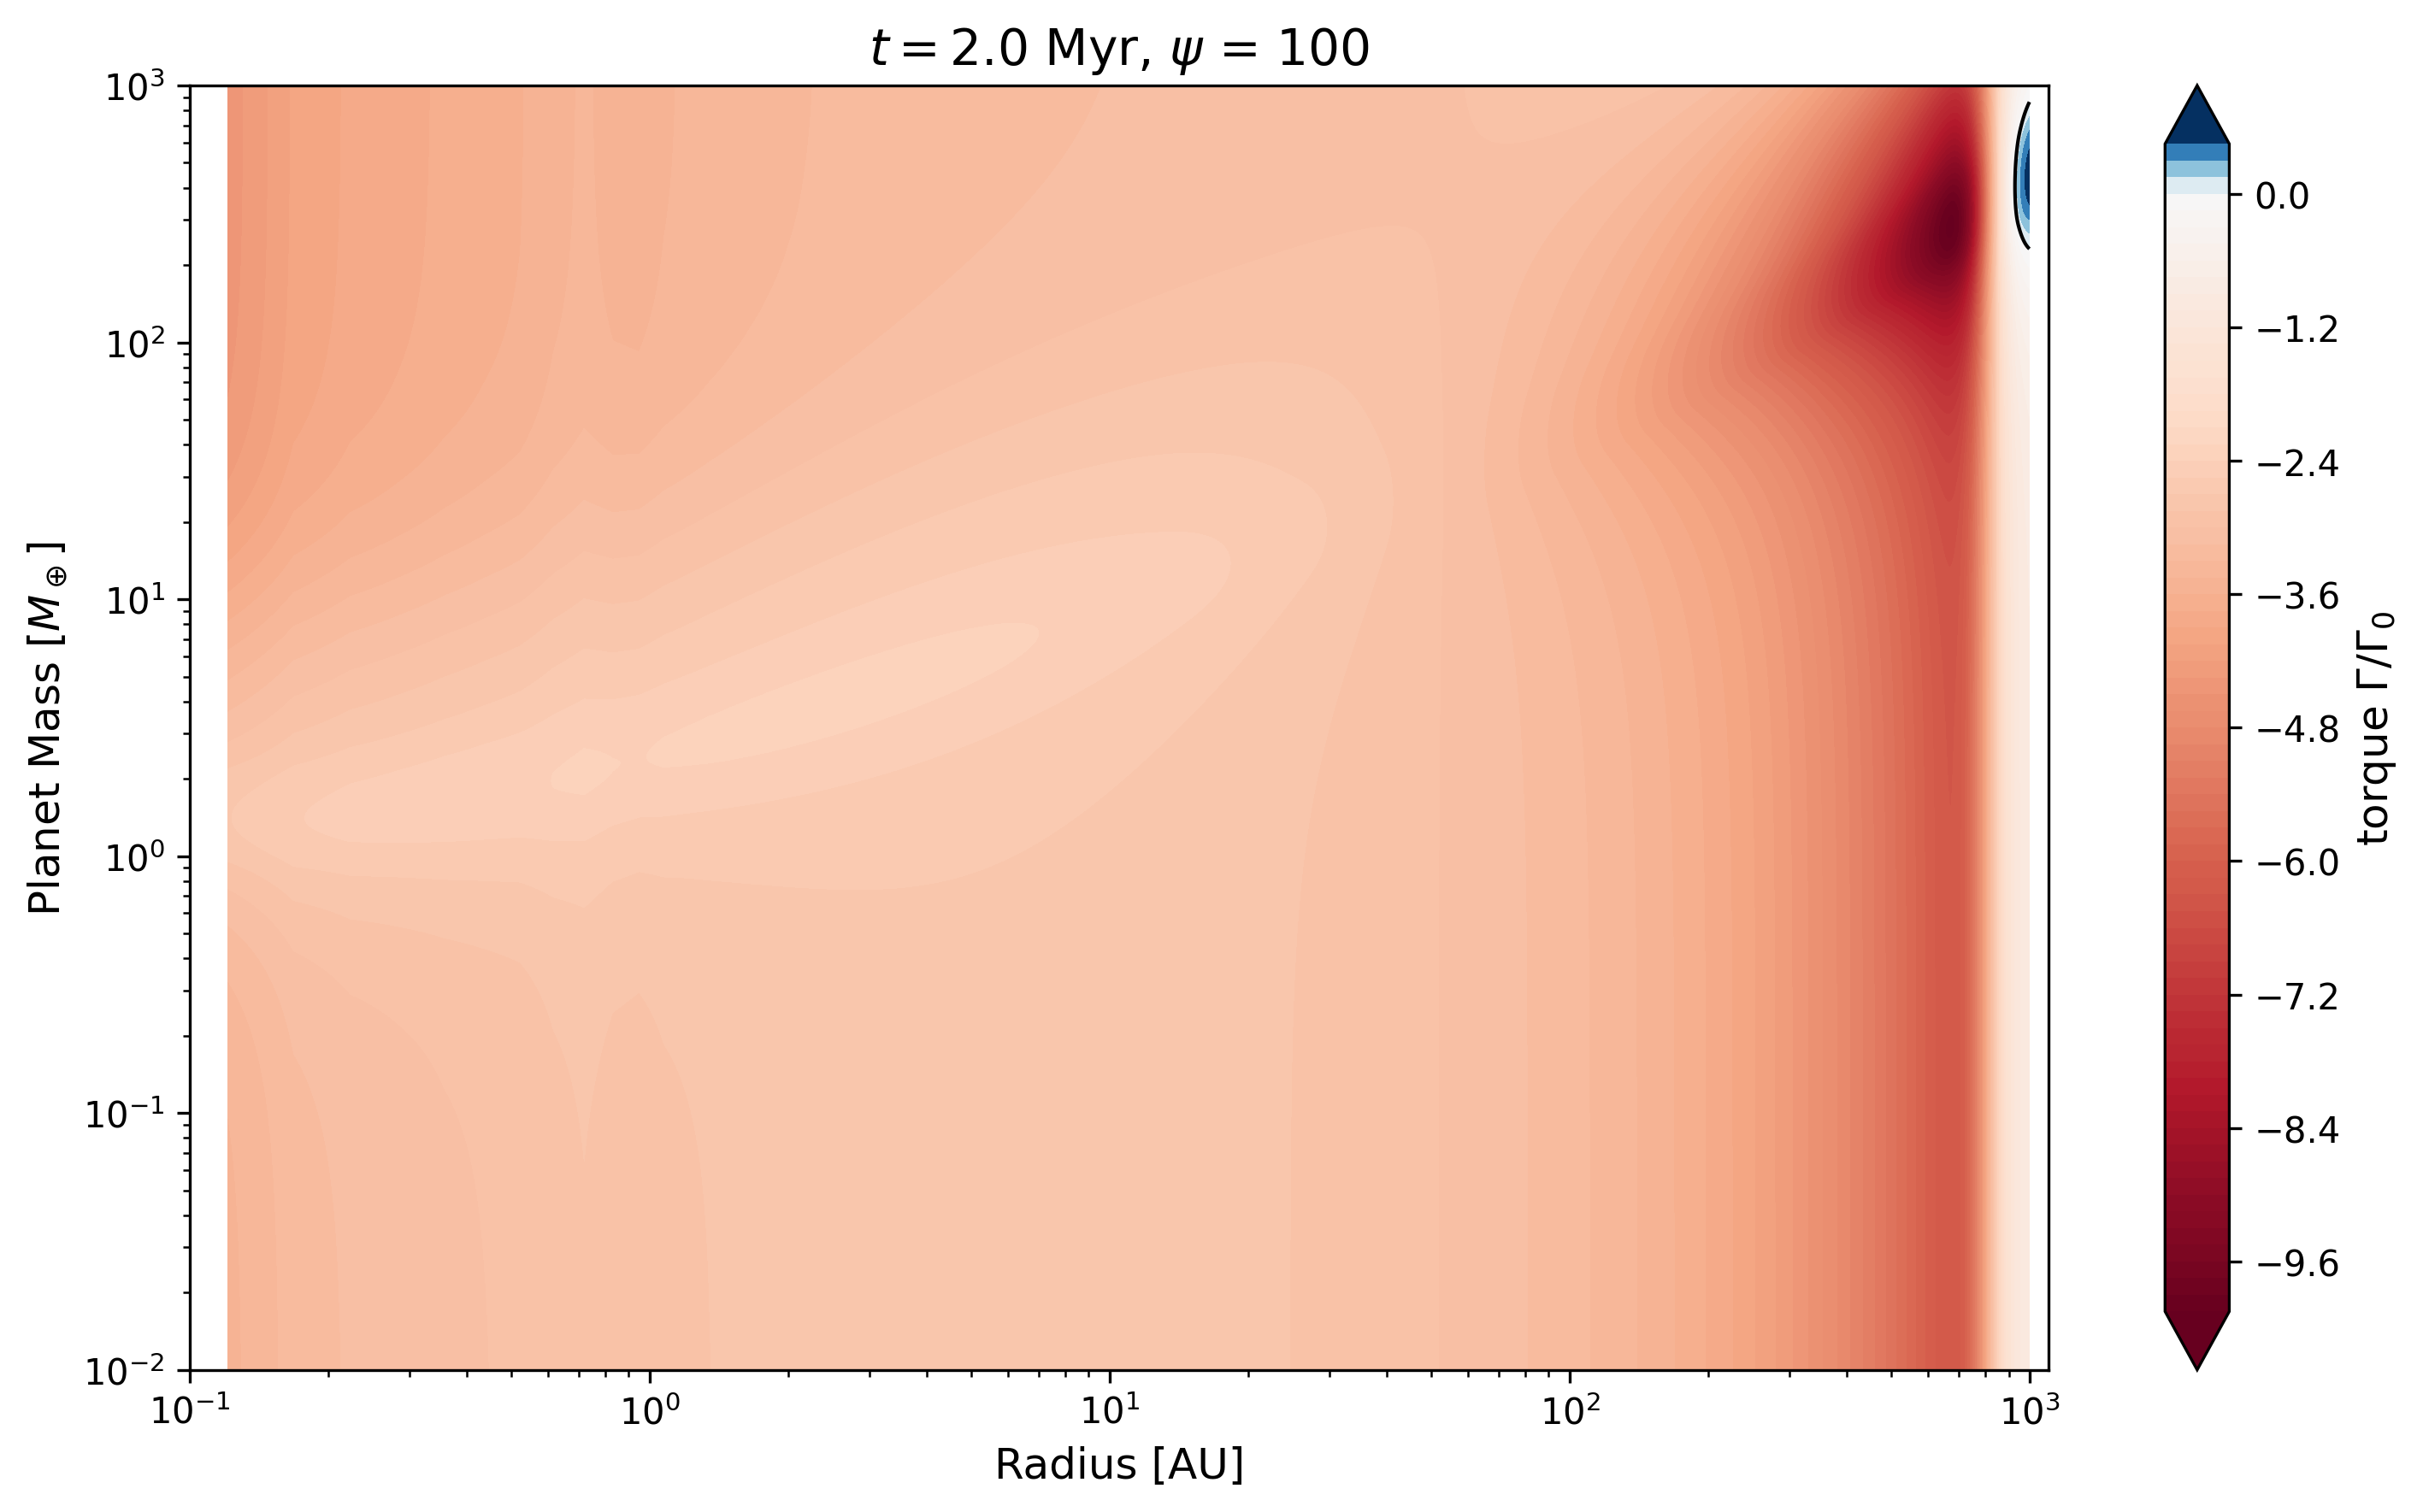

In [ ]:
disc._gas = visc_evol
from DiscEvolution import planet_formation as pf

# 1. Create Migration Model
TypeI = pf.TypeIMigration(disc) #Creates a Type I migration object from the disc object

# 2. Create M-R diagram 
mass_array = np.logspace(-2,3,Ncells) #Mearth required by compute_torque function
radius_array = disc.R #AU

R_grid, M_grid = np.meshgrid(radius_array, mass_array) #2D grid from two 1D arrays
Torque_map = np.zeros_like(R_grid) #initialize 2D grid with all values zero 

# 3. Compute Torques
for i, Mp in enumerate(mass_array):
    # Pass Mp as an array of the same shape as radius_array
    Mp_array = np.ones_like(radius_array) * Mp #entire row with said mass value
    # Compute the total torque for said mass at each R 
    Torque_map[i, :] = TypeI.compute_torque_raw(radius_array, Mp_array) #TODO get warnings after first import from the main method in planet_formation.py 

# 4. Normalize by Gamma_0
## The function already computes Gamma_0 (norm) and scales the torque with it, so we want to reverse this
## I created a new function that doesn't scale the torques so this step is not necessary anymore
##essentially instead of Gamma*Gamma_0 we return Gamma

# 5. Plot Torque Map 
from matplotlib import colors, ticker


fig, ax = plt.subplots(figsize=(10, 6))

# Colormap (Red = Inward/negative, Blue = Outward/Positive)
cmin = np.nanmin(Torque_map)
cmax = np.nanmax(Torque_map)
norm = colors.TwoSlopeNorm(vmin=cmin, vcenter=0.0, vmax=cmax)
#symmetric_levels = np.linspace(-5.0, 5.0, 100) #Explicitly define levels from -5 to +5
cp = ax.contourf(R_grid, M_grid, Torque_map, levels=100, cmap='RdBu', norm=norm, extend='both')

# Zero-Torque Planet Traps
trap_lines = ax.contour(R_grid, M_grid, Torque_map, levels=[0.0], colors='black', linewidths=1.0)

# Colorbar
cbar = plt.colorbar(cp, ax=ax)
cbar.set_label(rf'torque $\Gamma / \Gamma_0$', fontsize=12)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.1, 1100) 
#ax.set_ylim(0.1, 100)

ax.set_xlabel('Radius [AU]', fontsize=12)
ax.set_ylabel(rf'Planet Mass [$M_\oplus$]', fontsize=12)
ax.set_title(rf'$t = {driver.t / (1e6* 2 * np.pi)}$ Myr, $\psi$ = {disc._gas._psi}', fontsize=14)
    
plt.tight_layout()
plt.show()